In [ ]:
import os
os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray")


['chest_xray', 'test', 'train', 'val']

In [9]:
import tensorflow as tf
tf.config.experimental.set_memory_growth(
    tf.config.list_physical_devices('GPU')[0], True
) if tf.config.list_physical_devices('GPU') else None


In [10]:
import sys
print(sys.executable)


c:\Users\SEJAL LEWIS\tf_env\Scripts\python.exe


In [11]:
import os, shutil
import random
import numpy as np
import pandas as pd
import itertools
from tqdm import tqdm, tqdm_notebook
import cv2
from scipy import stats
from sklearn.metrics import confusion_matrix, roc_curve,auc, classification_report, precision_score, recall_score
from sklearn.linear_model import LinearRegression

import skimage
import skimage.segmentation
import copy
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: []


In [12]:
print(tf.__version__)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, MaxPooling2D, Conv2D, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.imagenet_utils import decode_predictions


2.10.0


# Loading the dataset

In [13]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 150

def get_data(data_dir):
    data = []
    
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img in os.listdir(path):
            img_path = os.path.join(path, img)

            try:
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # 🚨 Skip unreadable images
                if img_arr is None:
                    print(f"⚠️ Skipped: {img_path}")
                    continue

                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])

            except Exception as e:
                print(f"⚠️ Error with {img_path}: {e}")

    return data   # ⬅️ RETURN LIST (IMPORTANT)


In [14]:
train = get_data('C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/train')
test = get_data('C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/test')
val = get_data('C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/val')


⚠️ Skipped: C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/train\PNEUMONIA\.DS_Store
⚠️ Skipped: C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/train\NORMAL\.DS_Store
⚠️ Skipped: C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/val\PNEUMONIA\.DS_Store
⚠️ Skipped: C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/val\NORMAL\.DS_Store


# Data Visualization and Preprocessing

In [15]:
pneumonia = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/train/PNEUMONIA")
pneumonia_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/train/PNEUMONIA"


In [16]:
import os
print(os.getcwd())


c:\Users\SEJAL LEWIS\Pictures\MSc Project\HeilBlick\notebooks


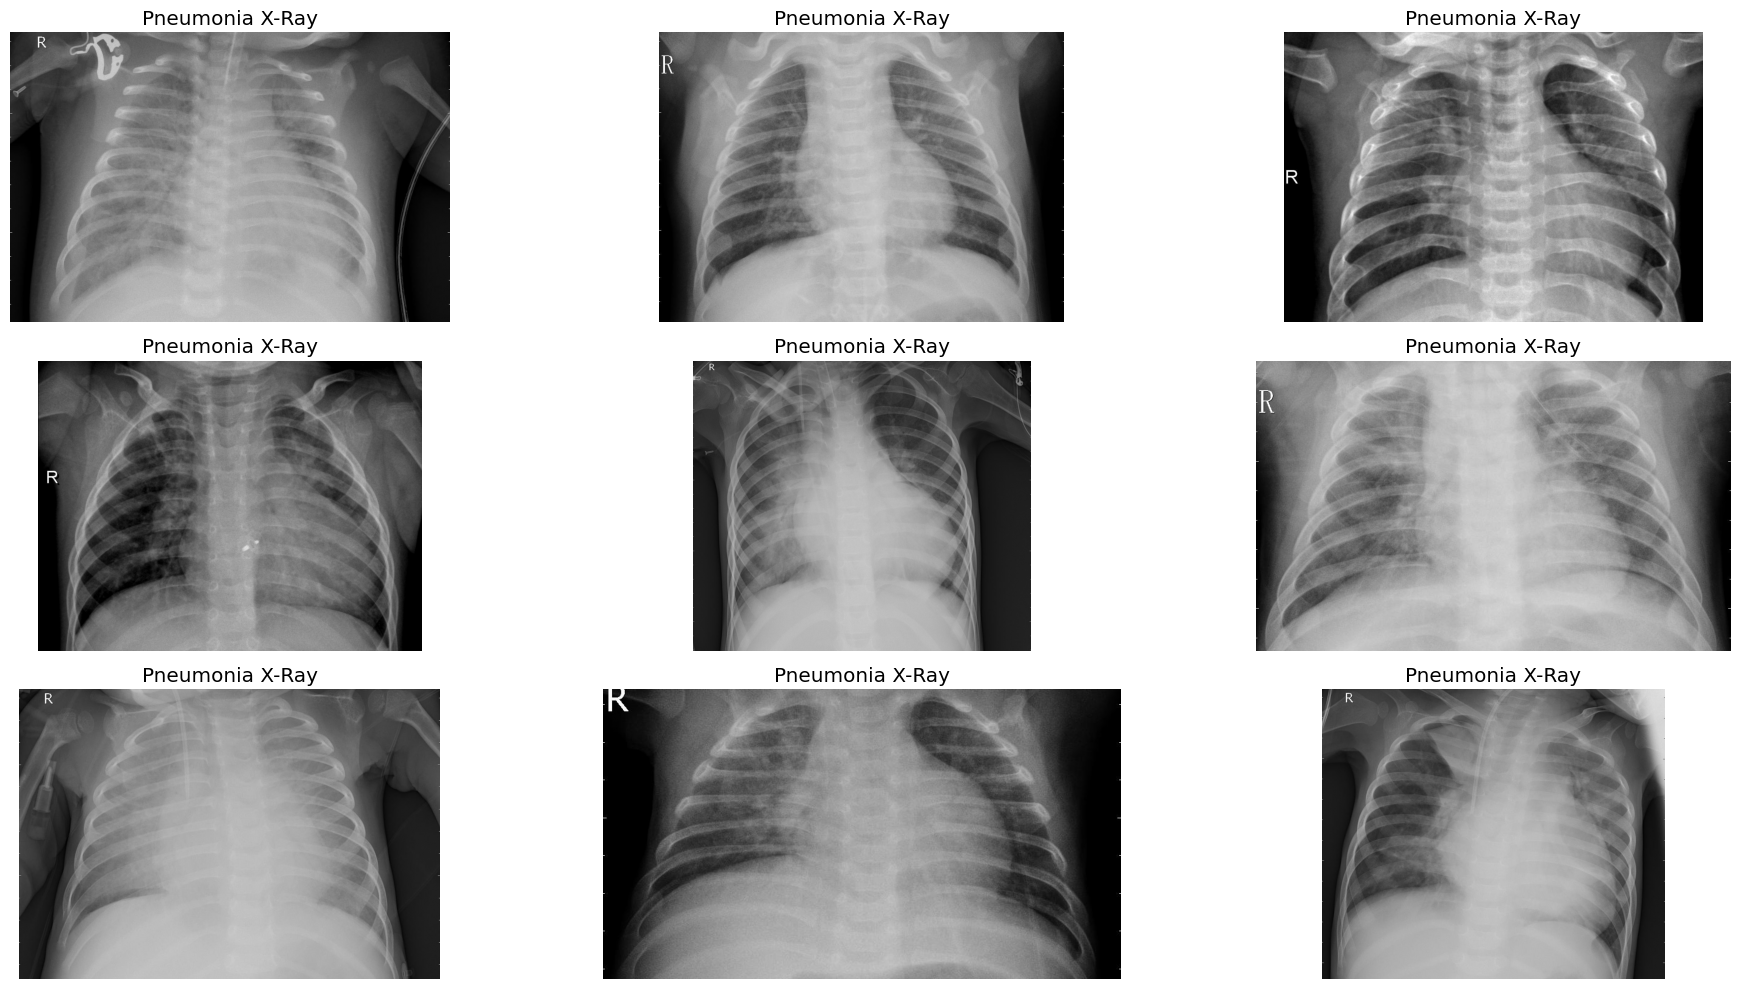

In [17]:
plt.figure(figsize=(20, 10))

image_files = [f for f in pneumonia if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img_path = os.path.join(pneumonia_dir, image_files[i])
    
    img = plt.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title("Pneumonia X-Ray")

plt.tight_layout()
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/pneumonia_xray_images.jpeg", dpi=200, bbox_inches='tight')
plt.show()


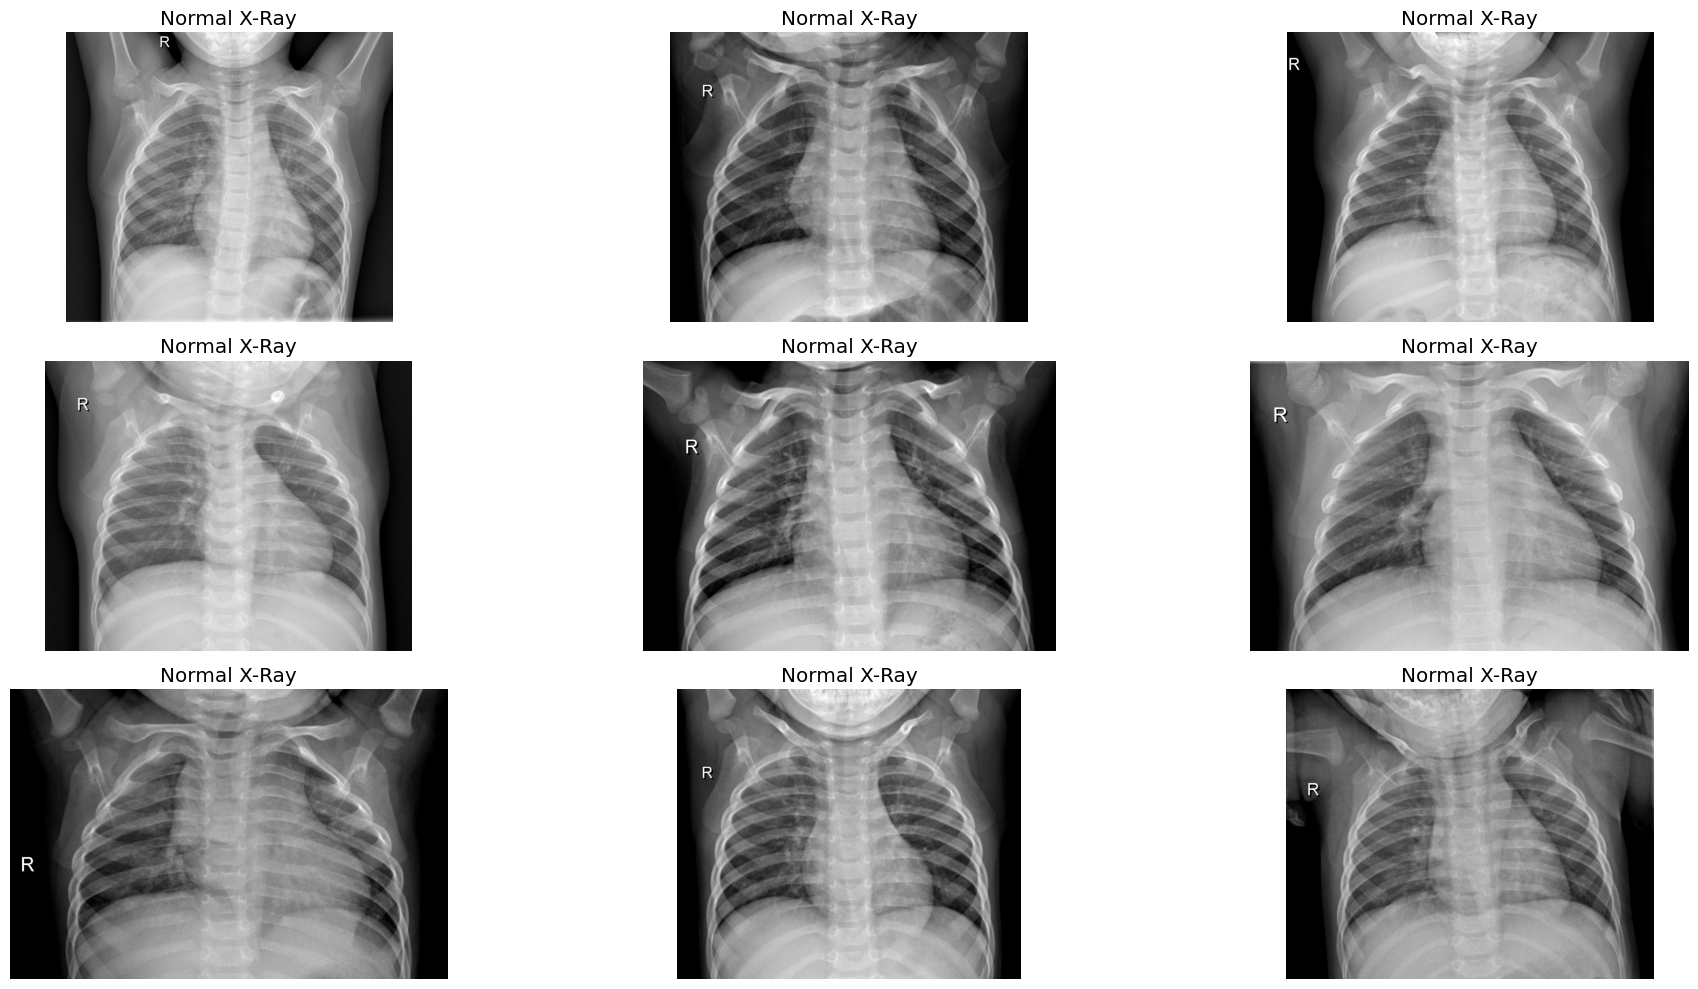

In [18]:
import os
import matplotlib.pyplot as plt

normal_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/chest_xray/train/NORMAL"

# keep only image files
normal = [f for f in os.listdir(normal_dir)
          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

plt.figure(figsize=(20, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(normal_dir, normal[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title("Normal X-Ray")

plt.tight_layout()
plt.savefig(
    "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/normal_xray_images.jpeg",
    dpi=200
)
plt.show()
plt.close()


<Axes: xlabel='count'>

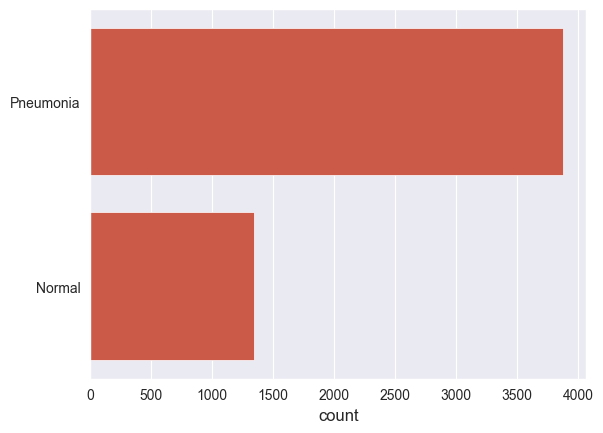

In [19]:
listx = []
for i in train:
    if(i[1] == 0):
        listx.append("Pneumonia")
    else:
        listx.append("Normal")
sns.set_style('darkgrid')
sns.countplot(listx)     


Text(0.5, 1.0, 'NORMAL')

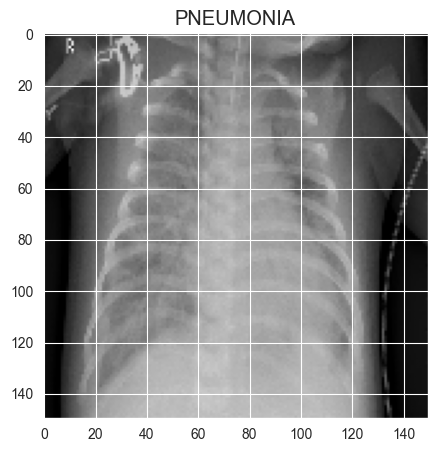

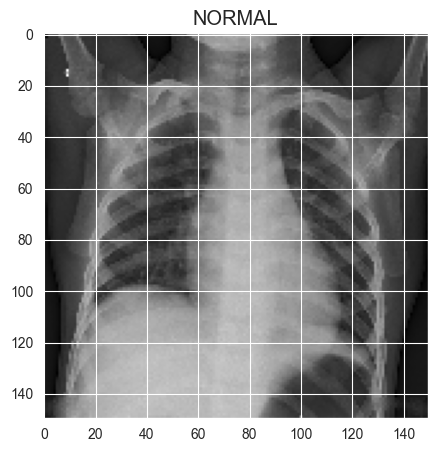

In [20]:
plt.figure(figsize = (5,5))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize = (5,5))
plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-1][1]])


In [21]:
train_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/train/"
test_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/test/"
valid_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/val/"


normal_train = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/train/NORMAL")
normal_train_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/train/NORMAL"
normal_val = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/val/NORMAL")
normal_val_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/val/NORMAL"
normal_test = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/test/NORMAL")
normal_test_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/test/NORMAL"

pneumonia_train = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/train/PNEUMONIA")
pneumonia_train_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/train/PNEUMONIA"
pneumonia_val = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/val/PNEUMONIA")
pneumonia_val_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/val/PNEUMONIA"
pneumonia_test = os.listdir("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/test/PNEUMONIA")
pneumonia_test_dir = "C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/data/pneumonia/chest_xray/test/PNEUMONIA"


In [22]:
print("{} Infected training images:".format(len(os.listdir(pneumonia_train_dir))))
print("{} Normal training images:".format(len(os.listdir(normal_train_dir))))
print(" {} Infected valid images:".format(len(os.listdir(pneumonia_val_dir))))
print(" {} Normal valid images:".format(len(os.listdir(normal_val_dir))))
print(" {} Infected testing images:".format(len(os.listdir(pneumonia_test_dir))))
print(" {} Normal testing images:".format(len(os.listdir(normal_test_dir))))


3875 Infected training images:
1341 Normal training images:
 8 Infected valid images:
 8 Normal valid images:
 390 Infected testing images:
 234 Normal testing images:


In [23]:
# Train
infected_trn_fpaths = [os.path.join(pneumonia_train_dir, fpath) for fpath in os.listdir(pneumonia_train_dir)]
healthy_trn_fpaths = [os.path.join(normal_train_dir, fpath) for fpath in os.listdir(normal_train_dir)]

# Valid
infected_valid_fpaths = [os.path.join(pneumonia_val_dir, fpath) for fpath in os.listdir(pneumonia_val_dir)]
healthy_valid_fpaths = [os.path.join(normal_val_dir, fpath) for fpath in os.listdir(normal_val_dir)]

# Test
infected_test_fpaths = [os.path.join(pneumonia_test_dir, fpath) for fpath in os.listdir(pneumonia_test_dir)]
healthy_test_fpaths = [os.path.join(normal_test_dir, fpath) for fpath in os.listdir(normal_test_dir)]


In [24]:
def get_img_shape(idx, img, total_num_images):
    
    if idx%2000 ==0 or idx == (total_num_images-1):
        print("working on img {}".format(idx))
    return cv2.imread(img).shape

data_inp = [(idx, img, len(infected_trn_fpaths + healthy_trn_fpaths)) for idx, img in enumerate(infected_trn_fpaths + healthy_trn_fpaths)]

train_img_dims_map = list(map(get_img_shape, [input[0] for input in data_inp],
    [input[1] for input in data_inp],
    [input[2] for input in data_inp]))


working on img 0
working on img 2000
working on img 4000
working on img 5215


In [25]:
print('Min Dimensions:           {}'.format(np.min(train_img_dims_map, axis=0)))
print('Avg Dimensions:           {}'.format(np.mean(train_img_dims_map, axis=0)))
print('Median Dimensions:        {}'.format(np.median(train_img_dims_map, axis=0)))
print('Most Frequent Dimensions: {}'.format(stats.mode(train_img_dims_map, axis=0)[0]))
print('Max Dimensions:           {}'.format(np.max(train_img_dims_map, axis=0)))


Min Dimensions:           [127 384   3]
Avg Dimensions:           [ 968.07476994 1320.61081288    3.        ]
Median Dimensions:        [ 888. 1284.    3.]
Most Frequent Dimensions: [ 736 1008    3]
Max Dimensions:           [2663 2916    3]


In [26]:
infected_trn_samples = random.sample(infected_trn_fpaths, 5)
healthy_trn_samples = random.sample(healthy_trn_fpaths, 5)


# Data augmentation and resizing images

In [27]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1,horizontal_flip=True
                                   )

valid_datagen = ImageDataGenerator(rescale=1.0/255.)
test_datagen = ImageDataGenerator(rescale=1.0/255.)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=8,
                                                    target_size=(128,128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

valid_generator = valid_datagen.flow_from_directory(valid_dir,
                                                    batch_size=8,
                                                    target_size=(128, 128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

class_labels = train_generator.class_indices
class_names = {value:key for (key, value) in class_labels.items()}


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [28]:
class_labels, class_names


({'NORMAL': 0, 'PNEUMONIA': 1}, {0: 'NORMAL', 1: 'PNEUMONIA'})

# Transfer Learning - VGG19 CNN Architecture

In [ ]:
# Instantiate VGG19 model with weights from Imagenet without the classifier at the top
base_model = VGG19(input_shape = (128,128,3),
                   include_top = False, 
                   weights = 'imagenet')
# Freeze the ConvNet to avoid weight updates
for layer in base_model.layers:
    layer.trainable=False
    
x = base_model.output
flat=GlobalAveragePooling2D()(x)

# Add a classifier -  a fully connected dense layers
class_1 = Dense(256, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(64, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

# Bake a model
model_01 = Model(base_model.inputs, output)
model_01.summary()

# Call backs
filepath = 'C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models/pneumonia.h5'
es = EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=4)
cp = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True,
                     save_weights_only=False, mode='auto', save_freq='epoch')
lrr = ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.5,min_lr=0.0001)

# Define an optimizer
sgd = SGD(learning_rate=.0001, decay=1e-6, momentum=0.9, nesterov=True)

# Compile the model
#model_01.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=["accuracy"])
model_01.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [ ]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: 1.9448173005219984, 1: 0.6730322580645162}


In [ ]:

history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=25,
    epochs=10,
    validation_data=valid_generator,
    callbacks=[es, cp, lrr],
    class_weight=class_weights
)


Epoch 1/10
25/25 [==============================] - ETA: 0s - loss: 0.7467 - accuracy: 0.6350
Epoch 1: val_loss improved from inf to 0.67232, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
25/25 [==============================] - 16s 588ms/step - loss: 0.7467 - accuracy: 0.6350 - val_loss: 0.6723 - val_accuracy: 0.6250 - lr: 1.0000e-04
Epoch 2/10
25/25 [==============================] - ETA: 0s - loss: 0.6685 - accuracy: 0.5700
Epoch 2: val_loss improved from 0.67232 to 0.63536, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
25/25 [==============================] - 17s 702ms/step - loss: 0.6685 - accuracy: 0.5700 - val_loss: 0.6354 - val_accuracy: 0.7500 - lr: 1.0000e-04
Epoch 3/10
25/25 [==============================] - ETA: 0s - loss: 0.6758 - accuracy: 0.6300
Epoch 3: val_loss improved from 0.63536 to 0.60951, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
25/2

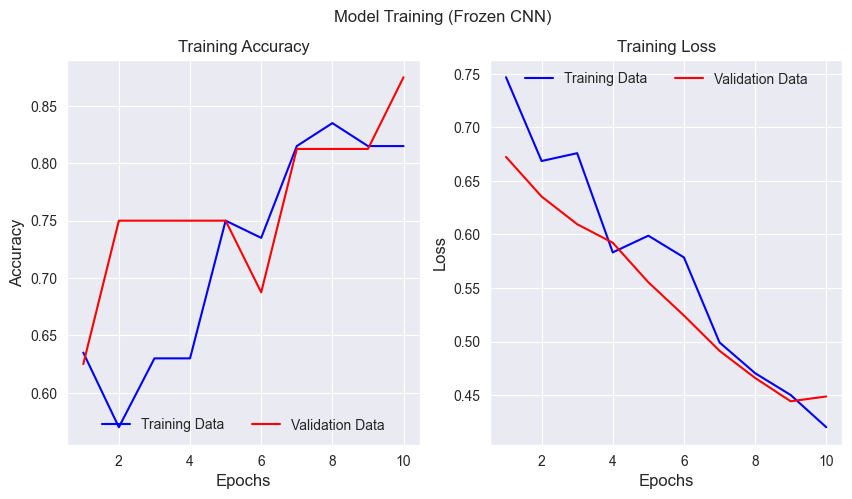

In [25]:
# Plot performance
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle("Model Training (Frozen CNN)", fontsize=12)
max_epoch = len(history_01.history['accuracy'])+1
epochs_list = list(range(1, max_epoch))

ax1.plot(epochs_list, history_01.history['accuracy'], color='b', linestyle='-', label='Training Data')
ax1.plot(epochs_list, history_01.history['val_accuracy'], color='r', linestyle='-', label='Validation Data')
ax1.set_title('Training Accuracy', fontsize=12)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(frameon=False, loc='lower center', ncol=2)

ax2.plot(epochs_list, history_01.history['loss'], color='b', linestyle='-', label='Training Data')
ax2.plot(epochs_list, history_01.history['val_loss'], color='r', linestyle='-', label='Validation Data')
ax2.set_title('Training Loss', fontsize=12)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(frameon=False, loc='upper center', ncol=2)
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/pneumonia_training_frozencnn.jpeg", format='jpeg', dpi=400, bbox_inches='tight')


In [26]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_01.save_weights(filepath='model_weights/vgg19_model_01.h5', overwrite=True)


In [31]:
# Resize test images similar to the train data
test_generator = test_datagen.flow_from_directory(test_dir,
                                                  batch_size=1,
                                                  target_size=(128, 128),
                                                  class_mode='categorical',
                                                  shuffle=False,
                                                  seed=42,
                                                  color_mode='rgb')


Found 624 images belonging to 2 classes.


In [28]:
# Load the saved model
model_01.load_weights('model_weights/vgg19_model_01.h5')
# Evaluate the model on the hold out validation and test datasets

# Evaluate the model on batches of validation and testing data
vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

print('Validation loss:     {0:.4f}'.format(vgg_val_eval_01[0]))
print('Validation accuracy: {0:.4f}'.format(vgg_val_eval_01[1]))
print('Test loss:           {0:.4f}'.format(vgg_test_eval_01[0]))
print('Test accuracy:       {0:.4f}'.format(vgg_test_eval_01[1]))


624/624 [==============================] - 71s 114ms/step - loss: 0.4851 - accuracy: 0.7917
Validation loss:     0.4487
Validation accuracy: 0.8750
Test loss:           0.4851
Test accuracy:       0.7917


In [32]:
filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_01 = model_01.predict(test_generator,
                                      steps = nb_samples,
                                      verbose=1)
vgg_pred_labels_01= np.argmax(vgg_predictions_01, axis=1)


624/624 [==============================] - 59s 94ms/step


In [30]:
# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_01, 
                            target_names=['NORMAL', 'PNEUMONIA']))
vgg_conf_mat_01 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_01), 
                        index=['NORMAL', 'PNEUMONIA'], 
                        columns=['NORMAL', 'PNEUMONIA'])


              precision    recall  f1-score   support

      NORMAL       0.75      0.66      0.70       234
   PNEUMONIA       0.81      0.87      0.84       390

    accuracy                           0.79       624
   macro avg       0.78      0.77      0.77       624
weighted avg       0.79      0.79      0.79       624



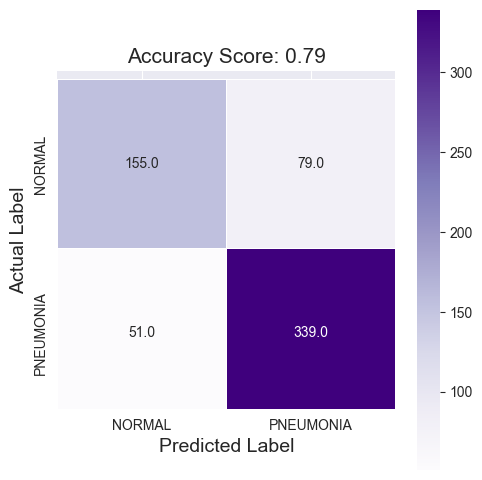

In [31]:
fig, ax = plt.subplots(figsize=(5,5))
#plt.figure(figsize=(9,9))
sns.heatmap(vgg_conf_mat_01, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Purples')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_01[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_01)-0.05, -0.05)
plt.tight_layout()


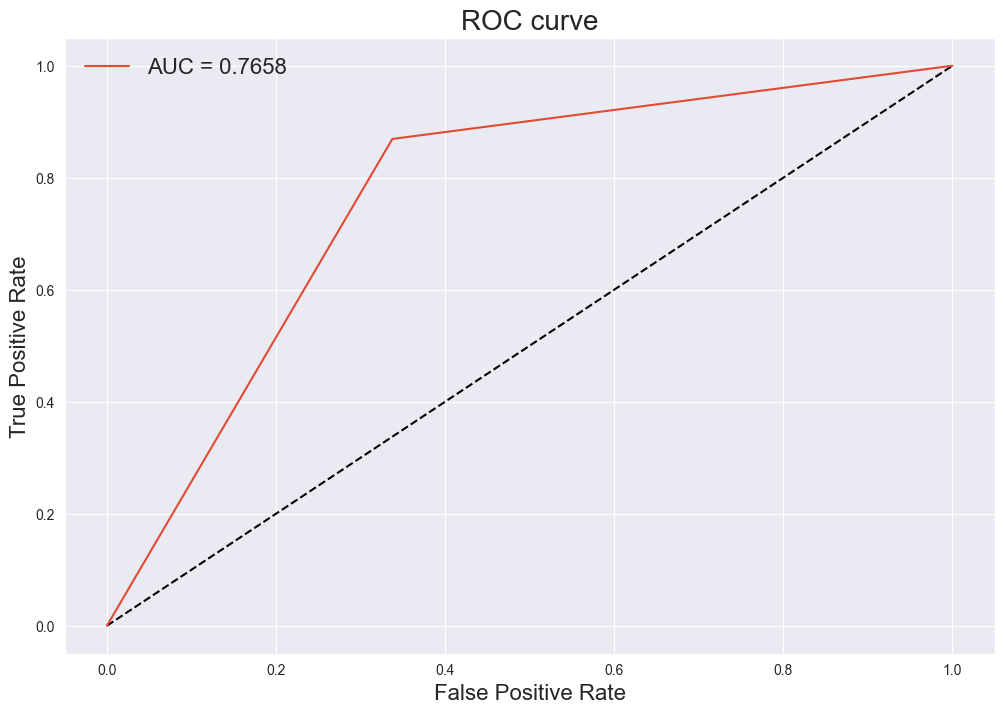

In [32]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_01)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.4f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)


# Incremental unfreezing and fine-tuning

In [33]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))
base_model_layer_names = [layer.name for layer in base_model.layers]
base_model_layer_names

x = base_model.output

flat=GlobalAveragePooling2D()(x)

class_1 = Dense(256, activation='relu')(flat)
drop_out = Dropout(0.3)(class_1)
class_2 = Dense(64, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_02 = Model(base_model.inputs, output)
model_02.load_weights('model_weights/vgg19_model_01.h5')

set_trainable = False
for layer in base_model.layers:
    if layer.name in ['block5_conv4', 'block5_conv3']:
        set_trainable=True
    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False

print(model_02.summary())


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [23]:
sgd = SGD(learning_rate=0.001, decay=1e-6, momentum=0.9, nesterov=True)
#model_02 = Model(base_model.inputs, output)
model_02.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [26]:
history_02 = model_02.fit(train_generator, steps_per_epoch=10, epochs=10, callbacks = [es, cp, lrr], validation_data = valid_generator)


Epoch 1/10
10/10 [==============================] - ETA: 0s - loss: 0.3843 - accuracy: 0.8125
Epoch 1: val_loss improved from inf to 0.54517, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
10/10 [==============================] - 8s 748ms/step - loss: 0.3843 - accuracy: 0.8125 - val_loss: 0.5452 - val_accuracy: 0.6250 - lr: 1.0000e-05
Epoch 2/10
10/10 [==============================] - ETA: 0s - loss: 0.3245 - accuracy: 0.8375
Epoch 2: val_loss did not improve from 0.54517
10/10 [==============================] - 7s 697ms/step - loss: 0.3245 - accuracy: 0.8375 - val_loss: 0.6006 - val_accuracy: 0.5625 - lr: 1.0000e-05
Epoch 3/10
10/10 [==============================] - ETA: 0s - loss: 0.3248 - accuracy: 0.8625
Epoch 3: val_loss improved from 0.54517 to 0.51246, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
10/10 [==============================] - 7s 731ms/step - loss: 0.3248 - accuracy: 0.8625 - val_loss

In [27]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_02.save_weights(filepath='model_weights/vgg19_model_02.h5', overwrite=True)


# Evaluating the model

624/624 [==============================] - 55s 88ms/step - loss: 0.4506 - accuracy: 0.7933
Validation loss:     0.5534532070159912
Validation accuracy: 0.75
Test loss:           0.45055800676345825
Test accuracy:       0.7932692170143127
624/624 [==============================] - 59s 94ms/step
              precision    recall  f1-score   support

     healthy       0.91      0.50      0.64       234
    infected       0.76      0.97      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.73      0.75       624
weighted avg       0.82      0.79      0.78       624



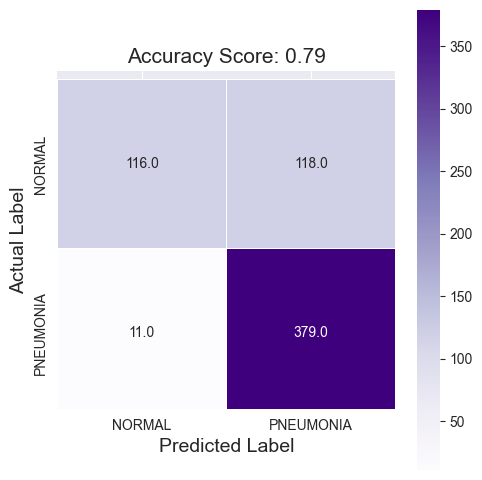

In [30]:
# Load the saved model
model_02.load_weights('model_weights/vgg19_model_02.h5')
# Evaluate the model on the hold out validation and test datasets

vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print('Validation loss:     {}'.format(vgg_val_eval_02[0]))
print('Validation accuracy: {}'.format(vgg_val_eval_02[1]))
print('Test loss:           {}'.format(vgg_test_eval_02[0]))
print('Test accuracy:       {}'.format(vgg_test_eval_02[1]))


filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_02 = model_02.predict(test_generator,
                                                steps = nb_samples,
                                                verbose=1)
vgg_pred_labels_02 = np.argmax(vgg_predictions_02, axis=1)


# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_02, 
                            target_names=['healthy', 'infected']))
vgg_conf_mat_02 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_02), 
                        index=['NORMAL', 'PNEUMONIA'], 
                        columns=['NORMAL', 'PNEUMONIA'])


fig, ax = plt.subplots(figsize=(5,5))

sns.heatmap(vgg_conf_mat_02, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Purples')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_02[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_02)-0.05, -0.05)
plt.tight_layout()


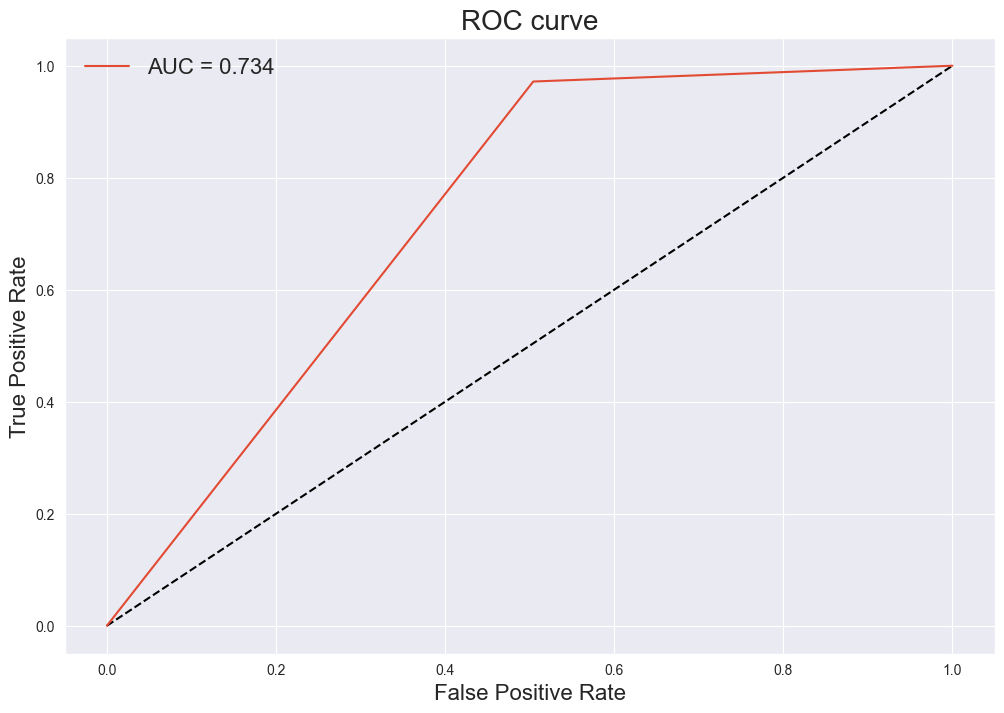

In [31]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_02)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.3f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)


# Unfreezing and fine-tuning the entire network

In [34]:
# Build the network
base_model = VGG19(include_top=False, input_shape=(128,128,3))
x = base_model.output
flat=GlobalAveragePooling2D()(x)
class_1 = Dense(256, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(64, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)
model_03 = Model(base_model.inputs, output)

# Load weights
model_03.load_weights('model_weights/vgg19_model_02.h5')

sgd = SGD(learning_rate=0.0001, decay=1e-6, momentum=0.9, nesterov=True)
# Compile the model
model_03.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])


In [27]:
history_03 = model_03.fit(train_generator,
                          steps_per_epoch=50,
                          epochs=10,
                          callbacks = [es, cp, lrr],
                          validation_data = valid_generator)


Epoch 1/10
50/50 [==============================] - ETA: 0s - loss: 0.2158 - accuracy: 0.9150
Epoch 1: val_loss improved from inf to 0.46956, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
50/50 [==============================] - 144s 3s/step - loss: 0.2158 - accuracy: 0.9150 - val_loss: 0.4696 - val_accuracy: 0.8125 - lr: 1.0000e-04
Epoch 2/10
50/50 [==============================] - ETA: 0s - loss: 0.2440 - accuracy: 0.9000
Epoch 2: val_loss improved from 0.46956 to 0.26893, saving model to C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/models\pneumonia.h5
50/50 [==============================] - 160s 3s/step - loss: 0.2440 - accuracy: 0.9000 - val_loss: 0.2689 - val_accuracy: 0.8125 - lr: 1.0000e-04
Epoch 3/10
50/50 [==============================] - ETA: 0s - loss: 0.2058 - accuracy: 0.9175
Epoch 3: val_loss did not improve from 0.26893
50/50 [==============================] - 179s 4s/step - loss: 0.2058 - accuracy: 0.9175 - val_loss: 0

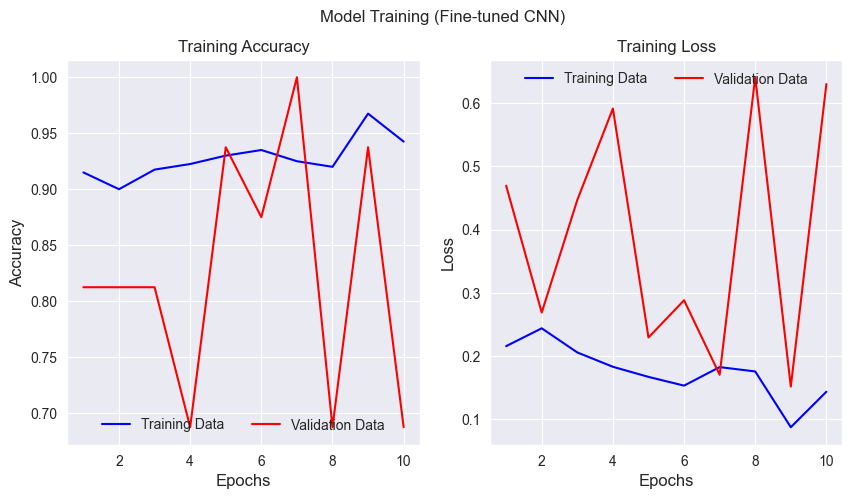

In [28]:
# Plot performance
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle("Model Training (Fine-tuned CNN)", fontsize=12)
max_epoch = len(history_03.history['accuracy'])+1
epochs_list = list(range(1, max_epoch))

ax1.plot(epochs_list, history_03.history['accuracy'], color='b', linestyle='-', label='Training Data')
ax1.plot(epochs_list, history_03.history['val_accuracy'], color='r', linestyle='-', label='Validation Data')
ax1.set_title('Training Accuracy', fontsize=12)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(frameon=False, loc='lower center', ncol=2)

ax2.plot(epochs_list, history_03.history['loss'], color='b', linestyle='-', label='Training Data')
ax2.plot(epochs_list, history_03.history['val_loss'], color='r', linestyle='-', label='Validation Data')
ax2.set_title('Training Loss', fontsize=12)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(frameon=False, loc='upper center', ncol=2)
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/pneumonia_training_finetunedcnn.jpeg", format='jpeg', dpi=400, bbox_inches='tight')


In [29]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_03.save_weights(filepath='model_weights/vgg_unfrozen.h5', overwrite=True)


# Evaluating the model

624/624 [==============================] - 74s 118ms/step - loss: 0.3955 - accuracy: 0.8542
Validation loss     :0.6304
Validation accuracy :0.6875
Test loss           :0.3955
Test accuracy       :0.8542
624/624 [==============================] - 81s 129ms/step
              precision    recall  f1-score   support

     healthy       0.97      0.63      0.76       234
    infected       0.82      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.85       624



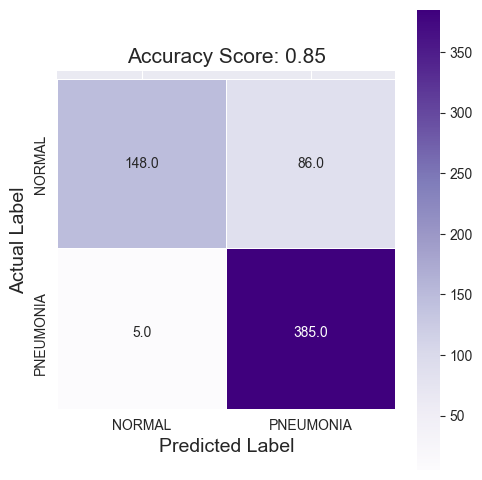

In [30]:
# Load the saved model
model_03.load_weights('model_weights/vgg_unfrozen.h5')
# Evaluate the model on the hold out validation and test datasets

vgg_val_eval_03 = model_03.evaluate(valid_generator)
vgg_test_eval_03 = model_03.evaluate(test_generator)

print('Validation loss     :{0:.4f}'.format(vgg_val_eval_03[0]))
print('Validation accuracy :{0:.4f}'.format(vgg_val_eval_03[1]))
print('Test loss           :{0:.4f}'.format(vgg_test_eval_03[0]))
print('Test accuracy       :{0:.4f}'.format(vgg_test_eval_03[1]))


filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_03 = model_03.predict(test_generator,
                                      steps = nb_samples,
                                      verbose=1)
vgg_pred_labels_03 = np.argmax(vgg_predictions_03, axis=1)


# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_03, 
                            target_names=['healthy', 'infected']))
vgg_conf_mat_03 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_03), 
                        index=['NORMAL', 'PNEUMONIA'], 
                        columns=['NORMAL', 'PNEUMONIA'])


fig, ax = plt.subplots(figsize=(5,5))

sns.heatmap(vgg_conf_mat_03, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Purples')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_03[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_03)-0.05, -0.05)
plt.tight_layout()


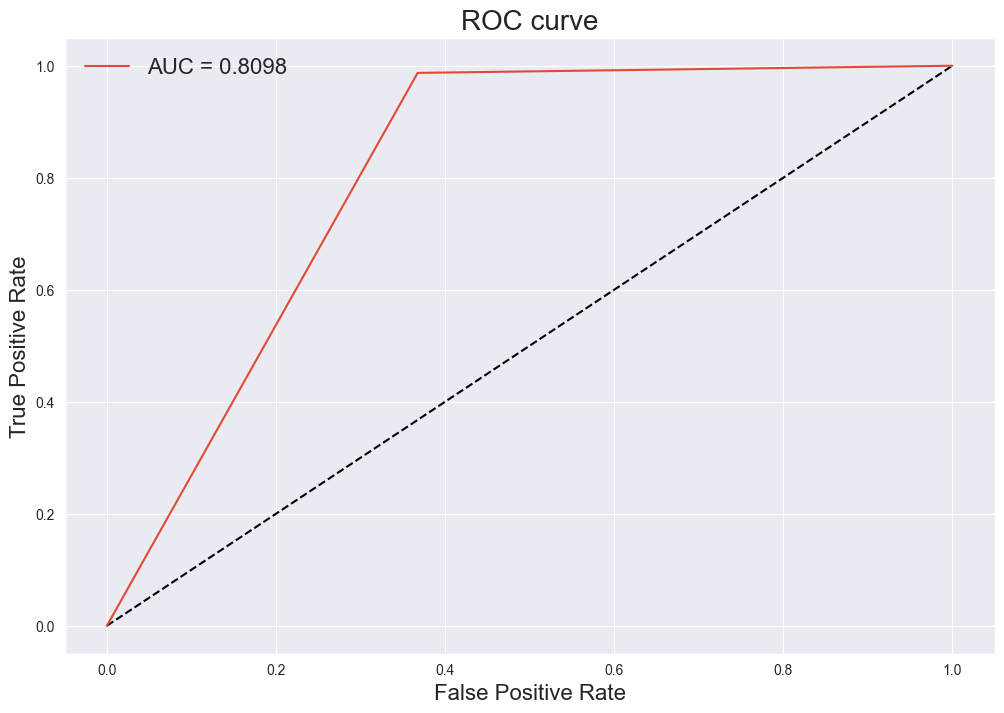

In [31]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_03)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.4f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)


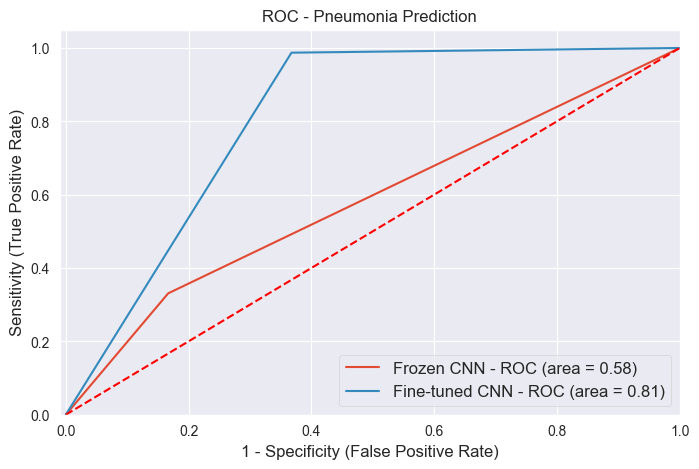

In [34]:
from sklearn import metrics
plt.figure(figsize=(8,5))
models = [
{
    'label': 'Frozen CNN',
    'model': model_01,
    'roc': vgg_pred_labels_01,
},
{
    'label': 'Fine-tuned CNN',
    'model': model_03,
    'roc': vgg_pred_labels_03,
}
]
for m in models:
    model = m['model']  
    false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, m['roc'])
    area_under_curve = auc(false_positive_rate, true_positive_rate)
    plt.plot(false_positive_rate, true_positive_rate, label='%s - ROC (area = %0.2f)' % (m['label'], area_under_curve))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Pneumonia Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/roc_pneumonia.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()


[80.13, 91.35]
[75.21, 89.15]


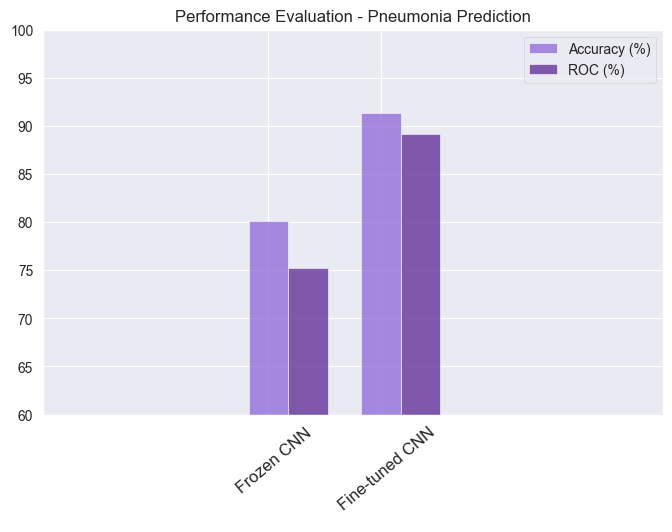

In [36]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
models = [
{
    'label': 'Frozen CNN',
    'model': model_01,
},
{
    'label': 'Fine-tuned CNN',
    'model': model_03,
}
]

# Test accuracy       :0.8013
# ROC                 :0.7521

# Test accuracy       :0.9135
# ROC                 :0.8915

means_roc = [75.21, 89.15]
means_accuracy = [80.13, 91.35]

print(means_accuracy)
print(means_roc)

# data to plot
n_groups = 2
means_accuracy = tuple(means_accuracy)
means_roc = tuple(means_roc)

# create plot
fig, ax = plt.subplots(figsize=(8,5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects2 = plt.bar(index, means_accuracy, bar_width,
alpha=opacity, 
color='mediumpurple',
label='Accuracy (%)')

rects3 = plt.bar(index + bar_width, means_roc, bar_width,
alpha=opacity, 
color='rebeccapurple',
label='ROC (%)')

plt.xlim([-2, 3.5])
plt.ylim([60, 100])

plt.title('Performance Evaluation - Pneumonia Prediction', fontsize=12)
plt.xticks(index, ('   Frozen CNN', '   Fine-tuned CNN'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/PE_pneumonia.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()


[43.31, 30.56]


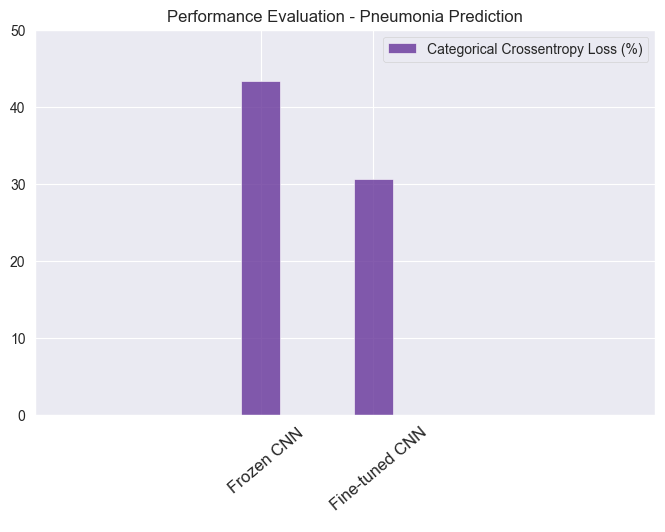

In [37]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
models = [
{
    'label': 'Frozen CNN',
    'model': model_01,
},
{
    'label': 'Fine-tuned CNN',
    'model': model_03,
}
]

# Test loss           :0.4331
# Test loss           :0.3056

means_loss = [43.31, 30.56]

print(means_loss)

# data to plot
n_groups = 2
means_loss = tuple(means_loss)

# create plot
fig, ax = plt.subplots(figsize=(8,5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, means_loss, bar_width,
alpha=opacity, 
color='rebeccapurple',
label='Categorical Crossentropy Loss (%)')

plt.xlim([-2, 3.5])
plt.ylim([0, 50])

plt.title('Performance Evaluation - Pneumonia Prediction', fontsize=12)
plt.xticks(index, ('   Frozen CNN', '   Fine-tuned CNN'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
# plt.legend(bbox_to_anchor =(1, 0.6), fontsize=12)
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/PE_pneumonia2.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()


# Prediction results for 10 randomly selected images

In [35]:
test_images = [img for img in random.sample(infected_test_fpaths, 5)]
test_images.extend([img for img in random.sample(healthy_test_fpaths, 5)])


1/1 [==============================] - 0s 93ms/step


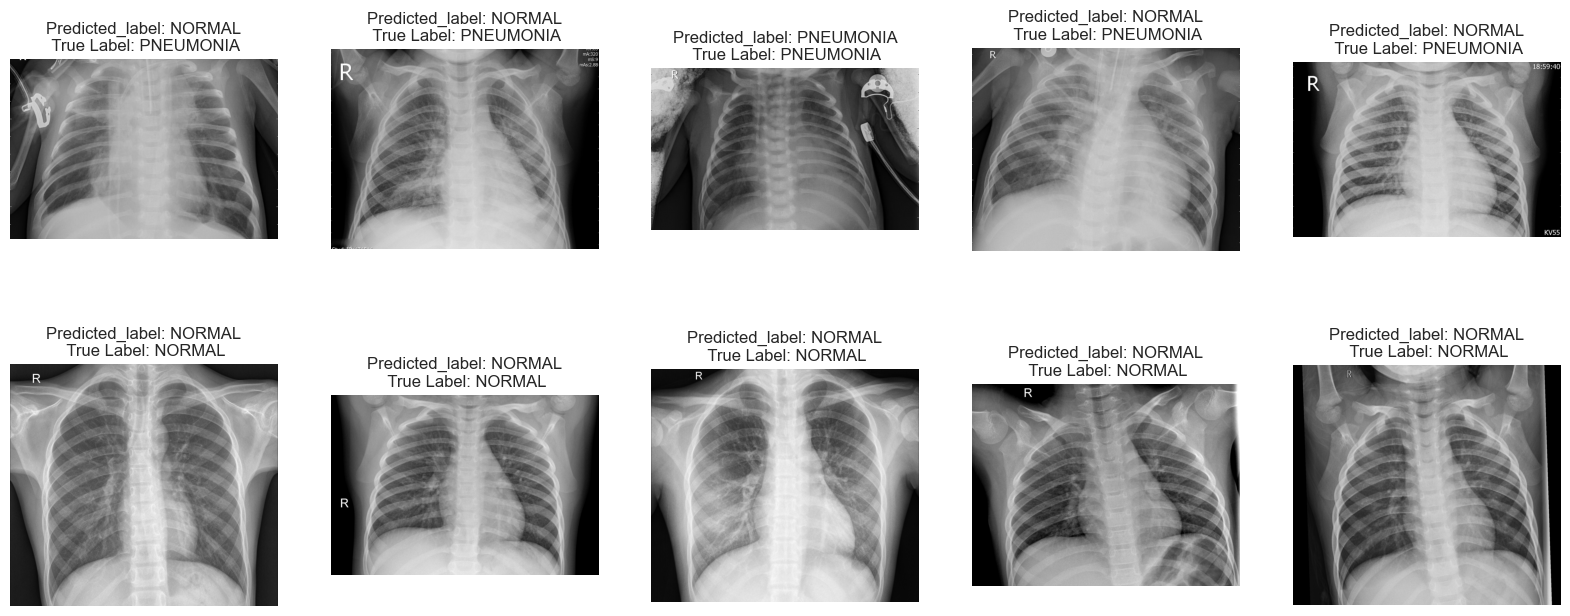

In [47]:
from keras.preprocessing.image import ImageDataGenerator
true_labels = []
predicted_labels = [] 
fig = plt.figure(figsize=(20,8))
columns=5
rows=2
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    true_label = true_labels.append(os.path.basename(os.path.dirname(test_images[i-1].split('/')[-1])))
    img = mpimg.imread(test_images[i-1])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    img = tf.keras.utils.load_img(test_images[i-1], target_size=(128,128))
    img = tf.keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis = 0)
    prediction = model_03.predict(img)
    predicted_label = np.argmax(prediction)
    plt.title('Predicted_label: {}\n True Label: {}'.format(class_names[predicted_label], true_labels[i-1]), fontsize=12)
plt.savefig("C:/Users/SEJAL LEWIS/Pictures/MSc Project/HeilBlick/outputs/pneumonia_predictions.jpeg", format='jpeg', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
